<a href="https://colab.research.google.com/github/vyakhyaagoyal/aiml_colab_sem-4/blob/main/matrix_theta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#make outputs easier to read
np.set_printoptions(precision=4, suppress=True)

In [ ]:
# Step 2
data=pd.DataFrame({
    "x":[1,2,3,5],
    "y":[4,6,7,15]
    })
print(data)
display(data)
print(len(data))

   x   y
0  1   4
1  2   6
2  3   7
3  5  15


,x,y
0,1,4
1,2,6
2,3,7
3,5,15


4


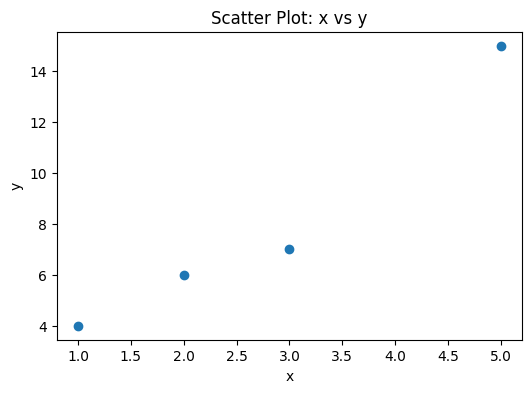

In [ ]:
# Step 3: Quick EDA (scatter plot)
plt.figure(figsize=(6,4))
plt.scatter(data["x"], data["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot: x vs y")
plt.show()

#this comes under regression

In [ ]:
u=np.ones(len(data))
print(u)
v=data["x"].values
print(v)

[1. 1. 1. 1.]
[1 2 3 5]


In [ ]:
#Step 4- build design matrix X and target vector Y
#add intercept term(ones column)
x=np.column_stack([np.ones(len(data)),data["x"].values])
y=data["y"].values.reshape(-1,1)

print("x=")
print(x)
print("\ny=")
print(y)
print("\nShapes -> x:", x.shape, ", y:", y.shape)

x=
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 5.]]

y=
[[ 4]
 [ 6]
 [ 7]
 [15]]

Shapes -> x: (4, 2) , y: (4, 1)


In [ ]:
#step 5- compute theta using normal equation
#theta=(x^t x)^(-1) x^t y
xt=x.T
xtx=xt@x
xty=xt@y

print("x^t x=")
print(xtx)
print("\nx^t y=")
print(xty)


x^t x=
[[ 4. 11.]
 [11. 39.]]

x^t y=
[[ 32.]
 [112.]]


In [ ]:
#INVERSE
xtx_inv=np.linalg.inv(xtx)
theta=xtx_inv @ xty

print("\n(x^t x)^(-1)=")
print(xtx_inv)

print("\nlearned parameters(theta)=")
print(theta)

theta0, theta1=float(theta[0,0]), float(theta[1,0])
#print()


(x^t x)^(-1)=
[[ 1.1143 -0.3143]
 [-0.3143  0.1143]]

learned parameters(theta)=
[[0.4571]
 [2.7429]]


In [ ]:
B=np.array([[1,2],
           [2,4]])
print(B)
print(B.T)
print(B*B)
print(B@B)

[[1 2]
 [2 4]]
[[1 2]
 [2 4]]
[[ 1  4]
 [ 4 16]]
[[ 5 10]
 [10 20]]


,x,y,y_pred,error
0,1,4,3.200000,-0.800000
1,2,6,5.942857,-0.057143
2,3,7,8.685714,1.685714
3,5,15,14.171429,-0.828571



Cost(J(theta))= 0.521429
MSE= 1.042857


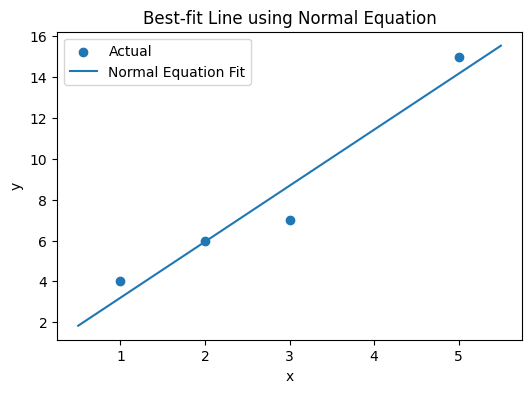

In [31]:
#step 6- final model and verification

#hypothesis function
#h(x)=theta0+theta1*x
def h(x):
  return theta0 + theta1*x

#compute predicted y-values for each x
data["y_pred"]=data["x"].apply(h)

#compute prediction error=predicted value-actual value
data["error"]=data["y_pred"]-data["y"]

#display updated table
display(data)

#compute cost J(theta) and MSE
m=len(data)
J=(1/(2*m)) * np.sum((data["y_pred"].values - data["y"].values)**2)
MSE=(1/m * np.sum((data["y_pred"].values - data["y"].values)**2))

print(f"\nCost(J(theta))= {J:.6f}")
print(f"MSE= {MSE:.6f}")

# Plot regression line
plt.figure(figsize=(6,4))
plt.scatter(data["x"], data["y"], label="Actual")
x_line = np.linspace(min(data["x"]) - 0.5, max(data["x"]) + 0.5, 50)
plt.plot(x_line, h(x_line), label="Normal Equation Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Best-fit Line using Normal Equation")
plt.legend()
plt.show()

#there will be always error in the prediction, it can never be perfect(staright line). our goal is to minimize the number of errors.